# 递归神经网络的变体

- $H_t = x_t W_i +  H_{t-1} W_h $

- 递归神经网络：
    - 具有时序记忆的特点。
    - 问题：
        - $H_t = x_t W_i  +  H_{t-1} 0.1$
        - 随着时序的长度的增加，时序前面的记忆的影响越来越低，直接到无影响（记忆衰退）

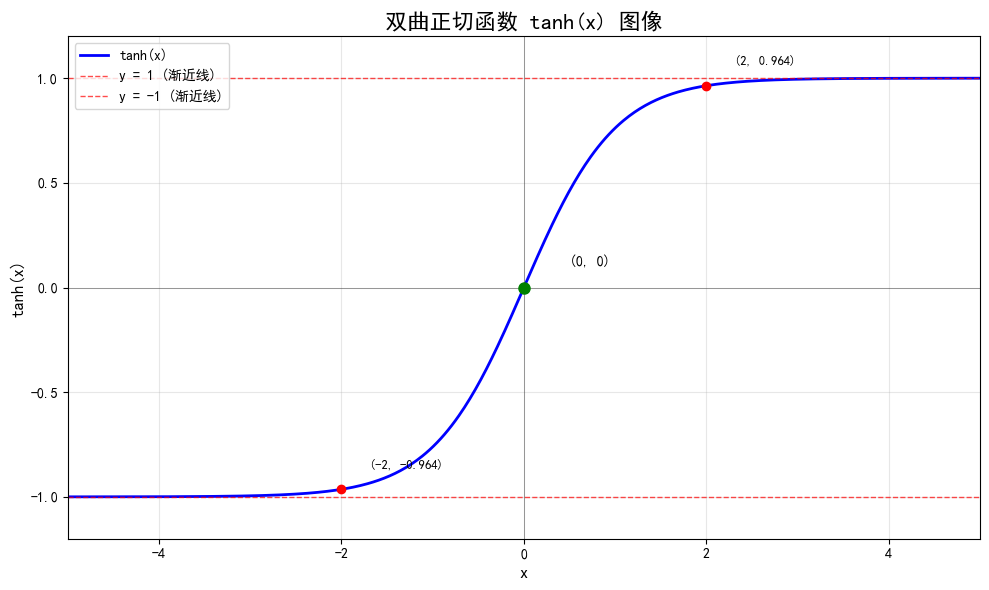

关键点数值：
tanh(0) = 0.0
tanh(1) = 0.7616
tanh(2) = 0.9640
tanh(-2) = -0.9640
tanh(∞) → 1
tanh(-∞) → -1


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体（可选，如果系统支持中文）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

# 生成 x 轴数据（在 -5 到 5 之间均匀取 500 个点）
x = np.linspace(-5, 5, 500)

# 计算对应的 tanh(x) 值
y = np.tanh(x)

# 创建图形
plt.figure(figsize=(10, 6))

# 绘制曲线
plt.plot(x, y, color='blue', linewidth=2, label='tanh(x)')

# 添加水平渐近线 y = 1 和 y = -1
plt.axhline(y=1, color='red', linestyle='--', linewidth=1, alpha=0.7, label='y = 1 (渐近线)')
plt.axhline(y=-1, color='red', linestyle='--', linewidth=1, alpha=0.7, label='y = -1 (渐近线)')

# 添加 x 轴和 y 轴参考线
plt.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
plt.axvline(x=0, color='black', linewidth=0.5, alpha=0.5)

# 设置坐标轴范围
plt.xlim(-5, 5)
plt.ylim(-1.2, 1.2)

# 添加网格
plt.grid(True, alpha=0.3)

# 设置标题和标签
plt.title('双曲正切函数 tanh(x) 图像', fontsize=16)
plt.xlabel('x', fontsize=12)
plt.ylabel('tanh(x)', fontsize=12)

# 显示图例
plt.legend(loc='upper left')

# 标注几个关键点
plt.plot(0, 0, 'go', markersize=8)  # 原点
plt.annotate('(0, 0)', xy=(0, 0), xytext=(0.5, 0.1), fontsize=10)

# 在 x = ±2 处添加示例点
x_marks = [-2, 2]
y_marks = np.tanh(x_marks)
plt.plot(x_marks, y_marks, 'ro', markersize=6)
for xm, ym in zip(x_marks, y_marks):
    plt.annotate(f'({xm}, {ym:.3f})', xy=(xm, ym), xytext=(xm+0.3, ym+0.1), fontsize=9)

# 显示图像
plt.tight_layout()
plt.show()

# 打印一些关键值
print("关键点数值：")
print(f"tanh(0) = {np.tanh(0)}")
print(f"tanh(1) = {np.tanh(1):.4f}")
print(f"tanh(2) = {np.tanh(2):.4f}")
print(f"tanh(-2) = {np.tanh(-2):.4f}")
print(f"tanh(∞) → 1")
print(f"tanh(-∞) → -1")

## 1. LSTM

- 为了强化对$X_t$与上一层的隐藏状态$H_{t-1}$的记忆

- 计算公式：
    - $i_t = \delta (W_{ii}x_t + b_{ii} + W_{hi}h_{t-1} + b_{hi})$
    - $f_t = \delta (W_{if}x_t + b_{if} + W_{hf}h_{t-1} + b_{hf})$
    - $g_t = \tanh  (W_{ig}x_t + b_{ig} + W_{hg}h_{t-1} + b_{hg})$
    - $o_t = \delta (W_{io}x_t + b_{io} + W_{ho}h_{t-1} + b_{ho})$
    - $c_t = f_t \odot c_{t-1} + i_t \odot g_t$   $\quad\quad\qquad$(长期记忆 + 短期记忆)
    - $h_t = o_t \odot \tanh(c_t)$
    - 其中$\odot$表示张量积。对应元素相乘。也使用$\otimes$表示。

- 是否记忆：
    - 重点看训练的两个权重$f_t$ 与 $g_t$
        - $f_t$为1，完全记忆，为0就是遗忘。

## 2. GRU

- 计算公式：
    - $r_t = \delta (W_{ir} x_t + b_{ir} + W_{hr} h_{t-1} + b_{hr})$
    - $z_t = \delta (W_{iz} x_t + b_{iz} + W_{hz} h_{t-1} + b_{hz})$
    - $n_t = \tanh  (W_{in} x_t + b_{in} + (W_{hn} h_{t-1} + b_{hn}) \odot r_t)$   $\qquad\qquad$ : 关键：当前 + 历史记忆
    - $h_t = (1-z_t) \odot n_t + z_t \odot h_{t-1}$   : 命名Gate的原因是：(1-z_t)与 z_t

# LSTM与GRU与RNN三个递归神经网络的应用

## 1. 构建一个基于GRU/LSTM/RNN的文本生成网络

- 重点是使用递归神经网络。

- 前提条件：
    - 输入的x.shape= `[batch_size, seq_len]`

```python
x = [
    [34, 56, 90, 23],
    [78, 234,123, 90],
    ...
]
```

In [4]:
import torch
from torch import nn
class  PoetryModel(nn.Module):   # 唐诗
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout, device="cpu", rnn_type="rnn"):
        super(PoetryModel, self).__init__()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        # shape = [vocab_size, embed_size]
        self.embedding = nn.Embedding(vocab_size, embed_size)  # 随机初始化（在任务中训练）
        # 使用RNN，LSTM，GRU构建循环神经网络
        self.rnn_type = rnn_type
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.device = device
        if rnn_type == "rnn":
            self.rnn = nn.RNN(
                input_size=embed_size,   # 输入大小就是一个词的词向量长度
                hidden_size=hidden_size,    # 随意设置，建议2的指数次方（表示特征的能力）
                num_layers=num_layers,      # 可以指定层数，层数建议1-2层。
                batch_first=True,  # 输入的数据格式：第一维必须是batch_size。
                bidirectional=False   # 递归神经网络是否单（双：True）向False
            )    
        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=embed_size,
                hidden_size=hidden_size, 
                num_layers=num_layers, 
                batch_first=True,
                bidirectional=False
            )
        elif rnn_type == "gru":
            self.rnn = nn.GRU(
                input_size=embed_size,
                hidden_size=hidden_size, 
                num_layers=num_layers, 
                batch_first=True,
                bidirectional=False
            )
        else:
            raise ValueError("网络模型必须是：rnn, lstm, gru") # 抛出异常
        # 激活函数 + dropout + 分类器
        self.fc = nn.Linear(self.hidden_size, self.vocab_size)   # 输出必须与词袋一样
        self.dropout = nn.Dropout(dropout)

        # self.hx =  # 自己初始化一个hidden

    def forward(self, x, hidden=None):
        """
            x.shape = [batch_size, seq_len]
        """
        # 1. 词嵌入运算
        embed = self.embedding(x)   # shape = [batch_size, seq_len, embed_size]
        # 2. 递归神经网络运算
        if hidden is None:
            if self.rnn_type == "lstm":
                h0 = torch.randn(self.num_layers, x.shape[0], self.hidden_size).to(self.device)
                c0 = torch.randn(self.num_layers, x.shape[0], self.hidden_size).to(self.device)
                hidden = (h0, c0)
            else:
                hidden = torch.randn(self.num_layers, x.shape[0], self.hidden_size).to(self.device)
            
        rnn_output, rnn_hidden = self.rnn(
            embed, 
            hidden     # 默认全部是0. 如果想自己设置，则可以传递，建议使用默认的h_x
        ) 
        # output.shape = [batch_size, seq_len, hidden_size]
        # hidden.shape = [num_layers, batch_size, hidden_size]
        # c_hidden.shape = hidden.shape
        # 运行dropout
        dropout_output = self.dropout(rnn_output)   # 可选
        # 分类运算
        final_outputs = self.fc(dropout_output) 
        
        return final_outputs, rnn_hidden   # 最后返回值在唐诗生成无用。

In [5]:
vocab_size = 70000  # 词袋的大小
embed_size = 200  # 词向量的大小
hidden_size = 64  # 递归神经网络的隐藏层大小
num_layers = 3
dropout = 0.2
model = PoetryModel(vocab_size, embed_size, hidden_size, num_layers, dropout, rnn_type="gru")
x = torch.tensor([
    [34, 56, 90, 23], 
    [78, 234,123, 90],
    # [78, 234,123, 90],
])

# hx = torch.randn(num_layers, x.shape[0], hidden_size)   # 自己初始化一个初始隐藏矩阵（0,1, 随机）
output, hidden = model(x)   # , hx)
print(output.shape)


torch.Size([2, 4, 70000])


## 2. 数据集

- 构建数据集：
    - 使用datasets框架构建数据集（txt. csv. json）
        - transformers框架的数据集兼容
    - 完全手工构造
        - 分词
        - 词频统计与词袋
            - 词袋大小
        - ids<->words
    - torch.utils.data.Dataset

### 2.1. 加载数据集

In [6]:
from datasets import load_dataset   # 读取数据集
from datasets import Features, Value, Sequence
import os

In [7]:
# 得到数据集的文件列表
data_dir = "./chinese-poetry/宋词"
# 列出文件
list_files = os.listdir(data_dir)
# 过滤不需要的文件
ci_files = [os.path.join(data_dir, file) for file in list_files if file.startswith("ci.song.")]

# 解析的字段
features = Features({
    "author": Value("string"),
    "paragraphs": Sequence(Value("string")),
    "rhythmic": Value("string"),
    "tags": Sequence(Value("string")),
    "prologue": Value("string")
})

# 按照描述的字段加载数据集
ci_dataset = load_dataset(
    "json", # 指定读取的格式：text，json，csv
    data_files=ci_files,
    features=features
)

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

In [8]:
ci_dataset

DatasetDict({
    train: Dataset({
        features: ['author', 'paragraphs', 'rhythmic', 'tags', 'prologue'],
        num_rows: 21053
    })
})

In [9]:
ci_dataset["train"][0]["paragraphs"]

['气和玉烛，睿化著鸿明。',
 '缇管一阳生。',
 '郊禋盛礼燔柴毕，旋轸凤凰城。',
 '森罗仪卫振华缨。',
 '载路溢欢声。',
 '皇图大业超前古，垂象泰阶平。',
 '岁时丰衍，九土乐升平。',
 '睹寰海澄清。',
 '道高尧舜垂衣治，日月并文明。',
 '嘉禾甘露登歌荐，云物焕祥经。',
 '兢兢惕惕持谦德，未许禅云亭。']

### 2.2. 预处理- 合并词，分词（Tokens）

In [10]:
# 合并的方式
def merge_function(sample):
    # 合并
    sample["paragraphs"] = "".join(sample["paragraphs"])
    return sample

merge_dataset = ci_dataset.map(merge_function, batched=False)
# map函数的操作：把ci_dataset的每个记录调用merge_function并传递给函数，函数处理后，返回处理的输出，形成新的数据集
# batched=True就是传递给函数的不是一条记录，而是1000条记录：批次处理True， False逐条处理

In [11]:
merge_dataset["train"][0]

{'author': '和岘',
 'paragraphs': '气和玉烛，睿化著鸿明。缇管一阳生。郊禋盛礼燔柴毕，旋轸凤凰城。森罗仪卫振华缨。载路溢欢声。皇图大业超前古，垂象泰阶平。岁时丰衍，九土乐升平。睹寰海澄清。道高尧舜垂衣治，日月并文明。嘉禾甘露登歌荐，云物焕祥经。兢兢惕惕持谦德，未许禅云亭。',
 'rhythmic': '导引',
 'tags': None,
 'prologue': None}

In [12]:
# 使用:G:\01技术资料\33深度学习\models\Qwen3-Embedding-0.6B
max_length = 128
# 加载分词器
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(r"G:\01技术资料\33深度学习\models\Qwen3-Embedding-0.6B")
# 唐诗宋词使用这种分词实际有问题：每个字就是一个词。
def token_function(sample):
    # 分词
    tokens = tokenizer(
        sample["paragraphs"], 
        truncation=True,
        max_length=max_length,
        padding=True,
        add_special_tokens=True
    )
    tokens["X"] = [toks[:-1] for toks in tokens["input_ids"]]  # 批次
    tokens["Y"] = [toks[1: ] for toks in tokens["input_ids"]]
    return tokens

token_dataset = merge_dataset.map(token_function, batched=True)


In [13]:
print(token_dataset["train"][0]) 

{'author': '和岘', 'paragraphs': '气和玉烛，睿化著鸿明。缇管一阳生。郊禋盛礼燔柴毕，旋轸凤凰城。森罗仪卫振华缨。载路溢欢声。皇图大业超前古，垂象泰阶平。岁时丰衍，九土乐升平。睹寰海澄清。道高尧舜垂衣治，日月并文明。嘉禾甘露登歌荐，云物焕祥经。兢兢惕惕持谦德，未许禅云亭。', 'rhythmic': '导引', 'tags': None, 'prologue': None, 'input_ids': [99180, 33108, 100658, 115257, 3837, 107198, 32108, 99610, 104594, 30858, 1773, 121088, 35551, 14777, 82075, 21287, 1773, 103074, 123269, 99681, 99748, 121828, 101545, 99764, 3837, 100917, 120092, 102729, 59074, 1773, 100739, 100349, 99966, 99417, 100096, 85361, 121540, 1773, 27366, 45995, 102764, 99352, 70074, 1773, 99767, 28029, 26288, 40952, 71304, 24562, 99470, 3837, 102566, 46423, 100396, 99736, 49111, 1773, 112436, 99638, 103403, 3837, 99609, 72990, 99350, 99294, 49111, 1773, 103772, 118082, 55135, 113668, 1773, 44793, 44636, 111599, 114823, 102566, 99741, 69905, 3837, 8903, 9754, 62926, 100704, 1773, 100731, 108252, 100818, 99760, 28641, 99678, 100670, 3837, 99718, 52853, 103493, 102197, 53393, 1773, 119467, 119467, 103114, 103114, 68878, 107486, 99462, 3837, 38342, 

- 去掉其他字段

In [14]:
token_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "X", "Y"])

In [15]:
print(token_dataset["train"][0])  # 保留input_ids与transformers框架兼容

{'input_ids': tensor([ 99180,  33108, 100658, 115257,   3837, 107198,  32108,  99610, 104594,
         30858,   1773, 121088,  35551,  14777,  82075,  21287,   1773, 103074,
        123269,  99681,  99748, 121828, 101545,  99764,   3837, 100917, 120092,
        102729,  59074,   1773, 100739, 100349,  99966,  99417, 100096,  85361,
        121540,   1773,  27366,  45995, 102764,  99352,  70074,   1773,  99767,
         28029,  26288,  40952,  71304,  24562,  99470,   3837, 102566,  46423,
        100396,  99736,  49111,   1773, 112436,  99638, 103403,   3837,  99609,
         72990,  99350,  99294,  49111,   1773, 103772, 118082,  55135, 113668,
          1773,  44793,  44636, 111599, 114823, 102566,  99741,  69905,   3837,
          8903,   9754,  62926, 100704,   1773, 100731, 108252, 100818,  99760,
         28641,  99678, 100670,   3837,  99718,  52853, 103493, 102197,  53393,
          1773, 119467, 119467, 103114, 103114,  68878, 107486,  99462,   3837,
         38342,  99454, 10

### 2.3. 批次数据集集

In [16]:
# 构建批次数据集
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding
# 对齐
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="max_length", max_length=max_length, return_tensors="pt")
# 批次数据集
dataloader = DataLoader(token_dataset["train"], batch_size=64, shuffle=True, collate_fn=data_collator)

In [17]:
for d in dataloader:
    print(d["X"].shape)
    break;

torch.Size([64, 127])


## 3. 训练模型

- 误差计算

In [20]:
# 模型
vocab_size = len(tokenizer.get_vocab())  # 词袋的大小
embed_size = 64  # 词向量的大小
hidden_size = 32  # 递归神经网络的隐藏层大小
num_layers = 2
dropout = 0.1
model = PoetryModel(vocab_size, embed_size, hidden_size, num_layers, dropout, device="cuda", rnn_type="lstm").to("cuda")
# 数据集
dataloader = DataLoader(token_dataset["train"], batch_size=8, shuffle=True, collate_fn=data_collator)
# 损失函数
criterion = nn.CrossEntropyLoss()
# 优化器
from torch import optim
optimizer = optim.Adam(model.parameters(), lr=0.001)
# 超参数
epoches = 2

In [21]:
print("开始训练...")
batch_size = 8

for e in range(epoches):
    model.train()
    total_loss = 0.0 
    for d in dataloader:
        X = d["X"].to("cuda")
        Y = d["Y"].to("cuda")
        # 梯度清零
        optimizer.zero_grad()
        # FF运算
        outputs, _ = model(X)   # 初始隐藏层使用默认：0
        # 计算损失（难度：）
        # outputs.shape(batch_size, seq_len, vocab_size)
        # Y.shape(batch_size, seq_length)
        loss = criterion(outputs.reshape(-1, vocab_size), Y.reshape(-1))  # 2维->1维（这个是损失的算法特点决定）
        # 自动求导
        loss.backward()
        # 梯度更新
        optimizer.step()
        # 输出损失值
        total_loss += loss.cpu().item()
    if e % 1 == 0:
        print(F"轮数：{e}，损失值：{total_loss/len(dataloader):.6f}")
        torch.save(model, "rnn.pt")
        print("保存模型：rnn.pt")
print("训练完毕")

开始训练...
轮数：0，损失值：4.238922
保存模型：rnn.pt
轮数：1，损失值：3.805512
保存模型：rnn.pt
轮数：2，损失值：3.746783
保存模型：rnn.pt
轮数：3，损失值：3.672662
保存模型：rnn.pt
轮数：4，损失值：3.595019
保存模型：rnn.pt


KeyboardInterrupt: 

- torch.no_grad()

## 4. 推理-生成唐诗

- 文本生成（无输入）
- 翻译（有输入）

In [29]:
num_predict = 20
start_char = "春"
token = tokenizer.encode(start_char, add_special_tokens=False)  # 不需要添加<EOS>特殊字符
predicts = []
with torch.no_grad():
    for _ in range(num_predict):
        # 处理token(维数，转换维张量)
        inputs = torch.tensor([token]).to("cuda")
        # 推理运算
        outputs, _ = model(inputs) 
        # 结果outputs.shape(batch_size, seq_len, vocan_size)
        predict = torch.argmax(outputs[0], dim=1).cpu().numpy()
        # 保存预测结果
        predicts.append(predict[-1])   # 因为只有一个整数，所以0与-1效果一样
        # 使用预测结果作为下轮推理的输入
        token = predict
    # print(predicts)
    # 转换为汉字
    text = "".join(tokenizer.decode(predicts))
    print(text)

花，枝花花月云月叶云花。云花风风月月，花
